In [1]:
import qutip
import matplotlib
from qutip.piqs.piqs  import *
import numpy as np
import os
os.environ["MOSEKLM_LICENSE_FILE"] = "/Users/a46668993/Desktop/qer/mosek/mosek.lic"  # adjust path
from noisemodel import*
from codewords import*
from optimisation import*

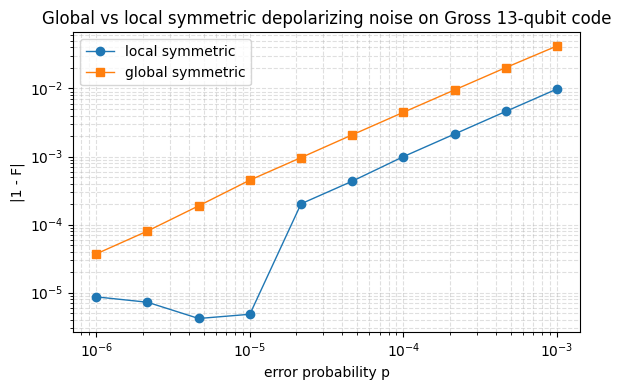

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from codewords import gross_13
from noisemodel import noisemodel
from optimisation import optimise 

rho, l0, l1 = gross_13(phi=0.0)
gamma = np.logspace(-5, -2, 10)
dt = 0.1

infids_local = []
infids_global = []

for g in gamma:
    kraus_global = noisemodel('global symmetric depolarizing', 13, g, dt)
    kraus_local = noisemodel('local symmetric depolarizing', 13, g, dt)

    fid_local = optimise(l0, l1, kraus_local, solver='mosek')
    fid_global = optimise(l0, l1, kraus_global, solver='mosek')

    infids_local.append(abs(1.0 - float(fid_local)))
    infids_global.append(abs(1.0 - float(fid_global)))

infids_local = np.array(infids_local, dtype=float)
infids_global = np.array(infids_global, dtype=float)
p_vals = gamma * dt

# avoid log(0)
mask_local = infids_local > 0
mask_global = infids_global > 0

plt.figure(figsize=(6, 4))
plt.loglog(p_vals[mask_local], infids_local[mask_local], "o-", lw=1, label="local symmetric")
plt.loglog(p_vals[mask_global], infids_global[mask_global], "s-", lw=1, label="global symmetric")
plt.xlabel("error probability p")
plt.ylabel("|1 - F|")
plt.title("Global vs local symmetric depolarizing noise on Gross 13-qubit code")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()
